In [1]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [2]:
df, scores = main(2023, 10000)

In [3]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #5518: 1400
Sim #5282: 1380
Sim #5337: 1370
Sim #3794: 1370
Sim #2809: 1350

BOTTOM 5 SCORES
Sim #8862: 170
Sim #87: 170
Sim #1067: 190
Sim #2456: 190
Sim #5661: 200

AVERAGE SCORE: 480.00


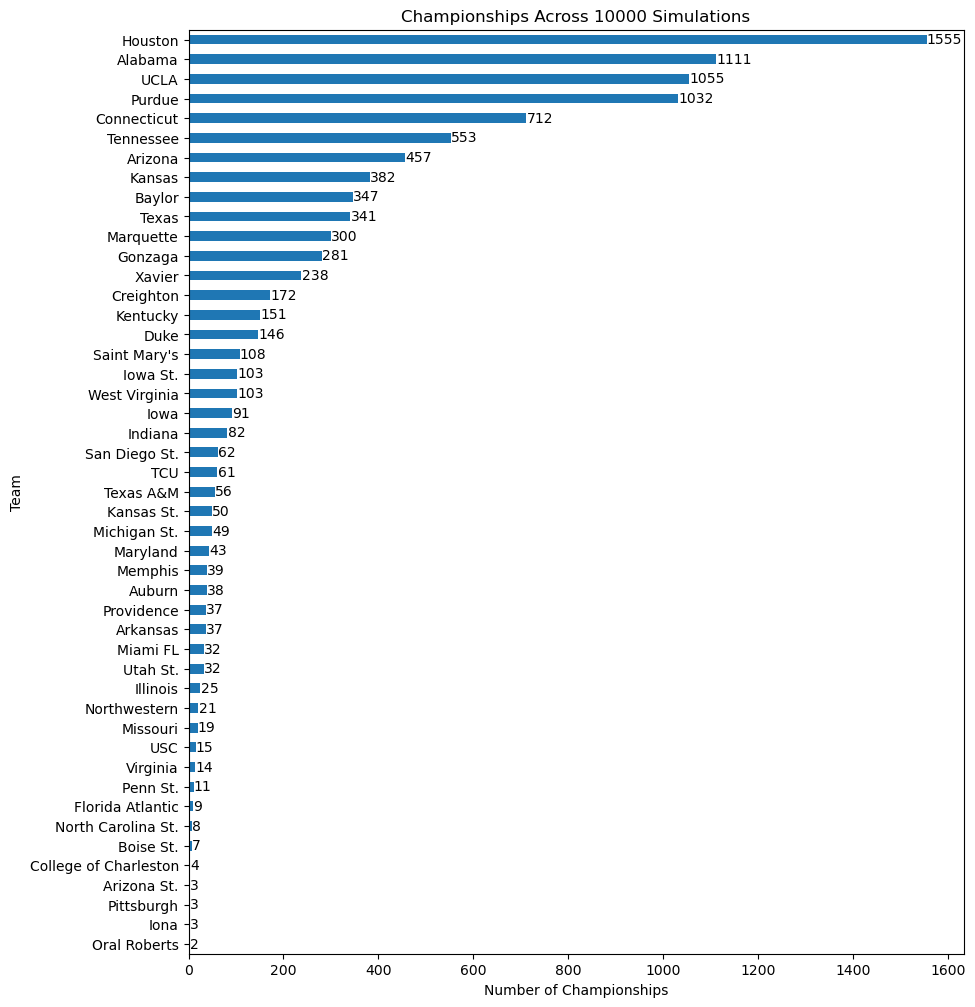

In [4]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 10000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [6]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 10000 Simulations

Houston           1555 --> 15.55%          Texas A&M          56 --> 0.56%            Oral Roberts        2 --> 0.02%         
Alabama           1111 --> 11.11%          Kansas St.         50 --> 0.5%             VCU                 0 --> 0.0%          
UCLA              1055 --> 10.55%          Michigan St.       49 --> 0.49%            Drake               0 --> 0.0%          
Purdue            1032 --> 10.32%          Maryland           43 --> 0.43%            Kent St.            0 --> 0.0%          
Connecticut       712 --> 7.12%            Memphis            39 --> 0.39%            Louisiana Lafayette   0 --> 0.0%        
Tennessee         553 --> 5.53%            Auburn             38 --> 0.38%            Furman              0 --> 0.0%          
Arizona           457 --> 4.57%            Arkansas           37 --> 0.37%            Grand Canyon        0 --> 0.0%          
Kansas            382 --> 3.82%            Providence         37 -

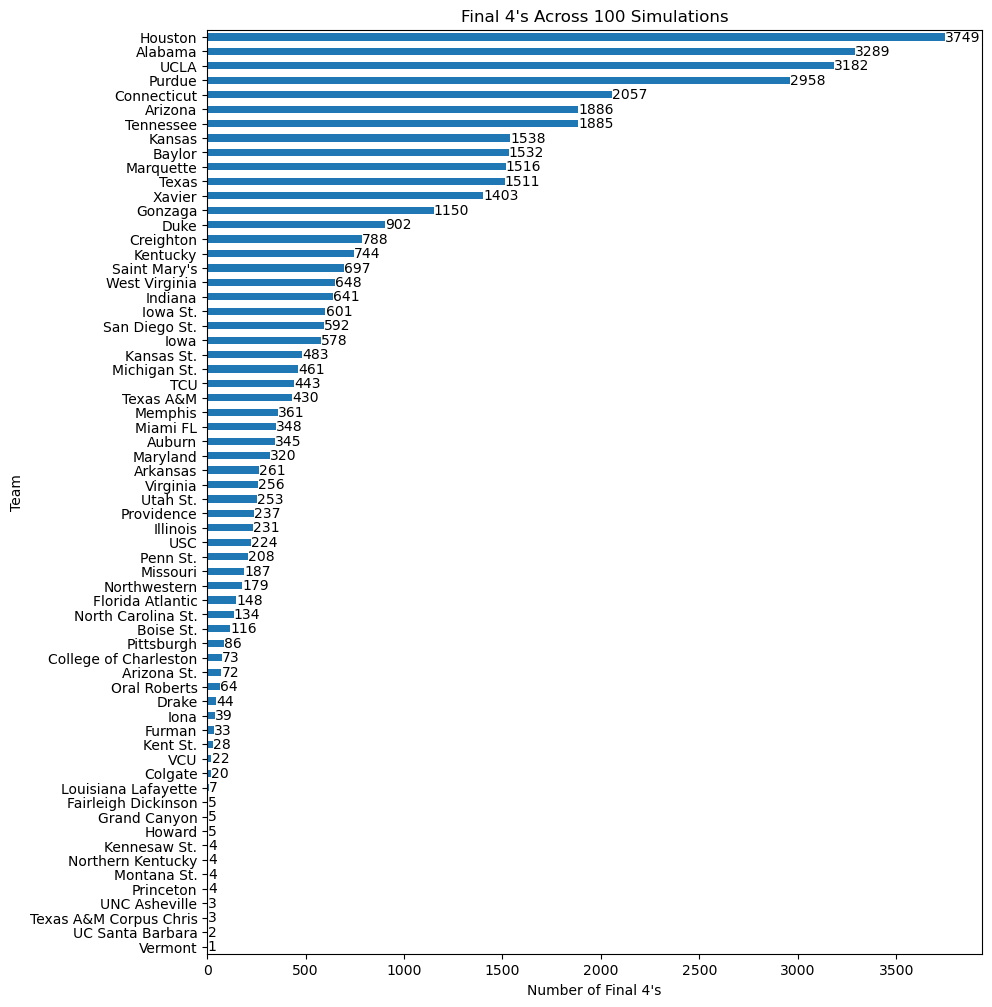

In [7]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 100 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [8]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 10000 Simulations

Houston           3749 --> 37.49%          Michigan St.      461 --> 4.61%            Drake              44 --> 0.44%         
Alabama           3289 --> 32.89%          TCU               443 --> 4.43%            Iona               39 --> 0.39%         
UCLA              3182 --> 31.82%          Texas A&M         430 --> 4.3%             Furman             33 --> 0.33%         
Purdue            2958 --> 29.58%          Memphis           361 --> 3.61%            Kent St.           28 --> 0.28%         
Connecticut       2057 --> 20.57%          Miami FL          348 --> 3.48%            VCU                22 --> 0.22%         
Arizona           1886 --> 18.86%          Auburn            345 --> 3.45%            Colgate            20 --> 0.2%          
Tennessee         1885 --> 18.85%          Maryland          320 --> 3.2%             Louisiana Lafayette   7 --> 0.07%       
Kansas            1538 --> 15.38%          Arkansas          261 --> 2

In [9]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 10000 Simulations

Houston           5187 --> 51.87%          TCU               1250 --> 12.5%           Oral Roberts      197 --> 1.97%         
UCLA              5028 --> 50.28%          Iowa              1145 --> 11.45%          Kent St.          184 --> 1.84%         
Alabama           4923 --> 49.23%          Texas A&M         1108 --> 11.08%          Furman            181 --> 1.81%         
Purdue            4104 --> 41.04%          Miami FL          962 --> 9.62%            Iona              129 --> 1.29%         
Arizona           3781 --> 37.81%          Memphis           781 --> 7.81%            VCU                96 --> 0.96%         
Connecticut       3561 --> 35.61%          Virginia          776 --> 7.76%            Colgate            92 --> 0.92%         
Marquette         3555 --> 35.55%          Maryland          755 --> 7.55%            Grand Canyon       49 --> 0.49%         
Kansas            3285 --> 32.85%          Auburn            750 --> 7

In [10]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 10000 Simulations

UCLA              7485 --> 74.85%          Virginia          2824 --> 28.24%          Drake             1020 --> 10.2%        
Arizona           6695 --> 66.95%          Michigan St.      2690 --> 26.9%           Pittsburgh        1011 --> 10.11%       
Purdue            6626 --> 66.26%          Texas A&M         2378 --> 23.78%          Oral Roberts      861 --> 8.61%         
Houston           6523 --> 65.23%          West Virginia     2315 --> 23.15%          Iona              478 --> 4.78%         
Alabama           6292 --> 62.92%          Iowa              2068 --> 20.68%          Colgate           451 --> 4.51%         
Kansas            6141 --> 61.41%          Memphis           2006 --> 20.06%          VCU               435 --> 4.35%         
Connecticut       5769 --> 57.69%          Arkansas          1973 --> 19.73%          Louisiana Lafayette 308 --> 3.08%       
Texas             5700 --> 57.0%           Providence        1955 -->

In [11]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
577926,9031,1,Howard,16,0,5,100.0,N/A,12.717,Kansas,13.058,Arkansas,8.291,Connecticut,14.146,Gonzaga,12.506,Xavier,9.977,Alabama,0.002
43854,686,1,UNC Asheville,15,0,5,100.0,N/A,9.366,UCLA,14.057,Northwestern,31.554,Grand Canyon,9.665,Illinois,11.814,Xavier,8.351,Alabama,0.004
433139,6768,4,College of Charleston,12,0,6,100.0,N/A,26.742,San Diego St.,32.970,Virginia,16.907,Alabama,29.081,Baylor,12.369,Purdue,13.356,Houston,0.007
341537,5337,3,Fairleigh Dickinson,16,1,4,100.0,N/A,9.567,Purdue,11.437,Florida Atlantic,9.991,Duke,10.023,Marquette,13.995,San Diego St.,0.000,N/A,0.009
9761,153,3,Fairleigh Dickinson,16,1,4,100.0,N/A,9.567,Purdue,11.437,Florida Atlantic,9.561,Tennessee,10.243,Kentucky,13.079,Alabama,0.000,N/A,0.009
430451,6726,4,College of Charleston,12,0,6,100.0,N/A,26.742,San Diego St.,32.970,Virginia,16.907,Alabama,22.439,Creighton,20.555,Marquette,12.580,Connecticut,0.009
313614,4901,1,UNC Asheville,15,0,4,100.0,N/A,9.366,UCLA,14.239,Boise St.,9.911,TCU,9.815,Connecticut,11.814,Xavier,0.000,N/A,0.011
570374,8913,1,Howard,16,0,4,100.0,N/A,12.717,Kansas,11.358,Illinois,8.291,Connecticut,10.822,UCLA,9.964,Houston,0.000,N/A,0.012
90894,1421,1,UNC Asheville,15,0,4,100.0,N/A,9.366,UCLA,14.239,Boise St.,9.911,TCU,9.815,Connecticut,9.623,Houston,0.000,N/A,0.012
12422,195,1,Howard,16,0,4,100.0,N/A,12.717,Kansas,13.058,Arkansas,8.291,Connecticut,10.822,UCLA,12.506,Xavier,0.000,N/A,0.013


In [12]:
df[df["sim_num"] == 5518].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
353091,5518,1,Connecticut,4,6,6,100.0,N/A,84.601,Iona,65.739,Saint Mary's,73.700,Arkansas,47.613,UCLA,56.996,Texas,72.627,San Diego St.,8.078
353146,5518,4,San Diego St.,5,5,5,100.0,N/A,73.258,College of Charleston,66.555,Virginia,24.911,Alabama,33.076,Arizona,23.632,Purdue,27.373,Connecticut,0.689
353117,5518,2,Texas,2,3,4,100.0,N/A,81.046,Colgate,72.058,Penn St.,77.742,Pittsburgh,68.531,Indiana,43.004,Connecticut,0.000,N/A,17.734
353132,5518,3,Purdue,1,0,4,100.0,N/A,90.433,Fairleigh Dickinson,71.962,Memphis,67.659,Duke,75.835,Kansas St.,76.368,San Diego St.,0.000,N/A,7.891
353101,5518,1,UCLA,2,2,3,100.0,N/A,90.634,UNC Asheville,82.741,Boise St.,55.709,Gonzaga,52.387,Connecticut,0.000,N/A,0.000,N/A,19.891
353108,5518,2,Indiana,4,1,3,100.0,N/A,71.729,Kent St.,60.785,Miami FL,23.459,Houston,31.469,Texas,0.000,N/A,0.000,N/A,7.010
353123,5518,3,Kansas St.,3,3,3,100.0,N/A,88.184,Montana St.,41.841,Kentucky,39.002,Marquette,24.165,Purdue,0.000,N/A,0.000,N/A,10.913
353137,5518,4,Arizona,2,0,3,100.0,N/A,89.665,Princeton,75.235,Missouri,57.634,Creighton,66.924,San Diego St.,0.000,N/A,0.000,N/A,12.860
353120,5518,3,Duke,5,1,2,100.0,N/A,73.340,Oral Roberts,42.609,Tennessee,32.341,Purdue,0.000,N/A,0.000,N/A,0.000,N/A,21.143
353089,5518,1,Arkansas,8,2,2,100.0,N/A,54.421,Illinois,28.797,Kansas,26.300,Connecticut,0.000,N/A,0.000,N/A,0.000,N/A,11.550


In [13]:
correct = df[df["Wins"] >=5] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 5).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Championship Games: ", len(filtered_df["sim_num"].unique()))

Number of Correct Championship Games:  19


In [15]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Final 4's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Final 4's:  0


In [16]:
correct = df[df["Wins"] >=3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Elite 8's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Elite 8's:  0


In [17]:
correct = df[df["Wins"] >=2] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 2).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Sweet 16's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Sweet 16's:  0


In [18]:
correct = df[df["Wins"] >=1] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 1).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Round of 32's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Round of 32's:  0


In [21]:
df[(df["TEAM"] == "Florida Atlantic") & (df["R32_opp"] == "Fairleigh Dickinson") & (df["S16_opp"] == "Tennessee") & (df["E8_opp"] == "Kansas St.")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
20066,314,3,Florida Atlantic,9,4,3,100.0,N/A,39.938,Memphis,88.563,Fairleigh Dickinson,22.631,Tennessee,48.029,Kansas St.,0.000,N/A,0.0,N/A,4.160
34338,537,3,Florida Atlantic,9,4,4,100.0,N/A,39.938,Memphis,88.563,Fairleigh Dickinson,22.631,Tennessee,48.029,Kansas St.,40.566,West Virginia,0.0,N/A,2.285
62562,978,3,Florida Atlantic,9,4,3,100.0,N/A,39.938,Memphis,88.563,Fairleigh Dickinson,22.631,Tennessee,48.029,Kansas St.,0.000,N/A,0.0,N/A,4.160
110434,1726,3,Florida Atlantic,9,4,3,100.0,N/A,39.938,Memphis,88.563,Fairleigh Dickinson,22.631,Tennessee,48.029,Kansas St.,0.000,N/A,0.0,N/A,4.160
320226,5004,3,Florida Atlantic,9,4,3,100.0,N/A,39.938,Memphis,88.563,Fairleigh Dickinson,22.631,Tennessee,48.029,Kansas St.,0.000,N/A,0.0,N/A,4.160
561314,8771,3,Florida Atlantic,9,4,4,100.0,N/A,39.938,Memphis,88.563,Fairleigh Dickinson,22.631,Tennessee,48.029,Kansas St.,34.780,Baylor,0.0,N/A,2.507


In [22]:
df[df["sim_num"] == 537].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
34367,537,4,West Virginia,9,0,6,100.0,N/A,56.015,Maryland,34.289,Alabama,72.630,College of Charleston,58.249,Utah St.,59.434,Florida Atlantic,54.26,Iowa,2.620
34325,537,2,Iowa,8,0,5,100.0,N/A,52.388,Auburn,36.690,Houston,49.893,Indiana,44.733,Texas,36.680,UCLA,45.74,West Virginia,0.854
34338,537,3,Florida Atlantic,9,4,4,100.0,N/A,39.938,Memphis,88.563,Fairleigh Dickinson,22.631,Tennessee,48.029,Kansas St.,40.566,West Virginia,0.00,N/A,2.285
34317,537,1,UCLA,2,2,4,100.0,N/A,90.634,UNC Asheville,82.741,Boise St.,83.528,Arizona St.,52.387,Connecticut,63.320,Iowa,0.00,N/A,12.036
34365,537,4,Utah St.,10,0,3,100.0,N/A,53.794,Missouri,26.544,Arizona,34.666,Baylor,41.751,West Virginia,0.000,N/A,0.00,N/A,2.883
34307,537,1,Connecticut,4,6,3,100.0,N/A,84.601,Iona,65.739,Saint Mary's,53.818,Kansas,47.613,UCLA,0.000,N/A,0.00,N/A,15.680
34339,537,3,Kansas St.,3,3,3,100.0,N/A,88.184,Montana St.,41.841,Kentucky,39.002,Marquette,51.971,Florida Atlantic,0.000,N/A,0.00,N/A,6.912
34333,537,2,Texas,2,3,3,100.0,N/A,81.046,Colgate,72.058,Penn St.,61.615,Iowa St.,55.267,Iowa,0.000,N/A,0.00,N/A,16.096
34324,537,2,Indiana,4,1,2,100.0,N/A,71.729,Kent St.,60.785,Miami FL,50.107,Iowa,0.000,N/A,0.000,N/A,0.00,N/A,21.754
34355,537,4,College of Charleston,12,0,2,100.0,N/A,26.742,San Diego St.,32.970,Virginia,27.370,West Virginia,0.000,N/A,0.000,N/A,0.00,N/A,6.404


In [24]:
df[df["sim_num"] == 6741].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
431379,6741,2,Houston,1,2,6,100.0,N/A,91.318,Northern Kentucky,80.269,Auburn,77.404,Miami FL,76.701,Iowa St.,59.067,UCLA,71.315,Duke,18.331
431392,6741,3,Duke,5,1,5,100.0,N/A,73.340,Oral Roberts,42.609,Tennessee,64.557,Florida Atlantic,49.115,Marquette,54.848,West Virginia,28.685,Houston,3.876
431373,6741,1,UCLA,2,2,4,100.0,N/A,90.634,UNC Asheville,81.589,Northwestern,73.359,TCU,52.387,Connecticut,40.933,Houston,0.000,N/A,16.786
431423,6741,4,West Virginia,9,0,4,100.0,N/A,56.015,Maryland,34.289,Alabama,53.965,San Diego St.,47.435,Creighton,45.152,Duke,0.000,N/A,2.697
431412,6741,4,Creighton,6,3,3,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,42.366,Arizona,52.565,West Virginia,0.000,N/A,0.000,N/A,6.275
431363,6741,1,Connecticut,4,6,3,100.0,N/A,84.601,Iona,65.739,Saint Mary's,53.818,Kansas,47.613,UCLA,0.000,N/A,0.000,N/A,15.680
431382,6741,2,Iowa St.,6,0,3,100.0,N/A,65.805,Pittsburgh,43.704,Xavier,38.385,Texas,23.299,Houston,0.000,N/A,0.000,N/A,8.467
431398,6741,3,Marquette,2,1,3,100.0,N/A,90.238,Vermont,59.623,Michigan St.,61.526,Kentucky,50.885,Duke,0.000,N/A,0.000,N/A,16.258
431394,6741,3,Florida Atlantic,9,4,2,100.0,N/A,39.938,Memphis,88.563,Fairleigh Dickinson,35.443,Duke,0.000,N/A,0.000,N/A,0.000,N/A,22.834
431385,6741,2,Miami FL,5,4,2,100.0,N/A,69.388,Drake,67.626,Kent St.,22.596,Houston,0.000,N/A,0.000,N/A,0.000,N/A,36.322


In [25]:
df[(df["TEAM"] == "Miami FL") & (df["R32_opp"] == "Indiana") & (df["S16_opp"] == "Houston") & (df["E8_opp"] == "Texas") & (df["F4_opp"] == "Connecticut")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
30425,476,2,Miami FL,5,4,4,100.0,N/A,69.388,Drake,39.215,Indiana,22.596,Houston,35.023,Texas,19.961,Connecticut,0.0,N/A,1.724
42841,670,2,Miami FL,5,4,4,100.0,N/A,69.388,Drake,39.215,Indiana,22.596,Houston,35.023,Texas,19.961,Connecticut,0.0,N/A,1.724
94425,1476,2,Miami FL,5,4,4,100.0,N/A,69.388,Drake,39.215,Indiana,22.596,Houston,35.023,Texas,19.961,Connecticut,0.0,N/A,1.724
214937,3359,2,Miami FL,5,4,4,100.0,N/A,69.388,Drake,39.215,Indiana,22.596,Houston,35.023,Texas,19.961,Connecticut,0.0,N/A,1.724
226521,3540,2,Miami FL,5,4,4,100.0,N/A,69.388,Drake,39.215,Indiana,22.596,Houston,35.023,Texas,19.961,Connecticut,0.0,N/A,1.724
285913,4468,2,Miami FL,5,4,4,100.0,N/A,69.388,Drake,39.215,Indiana,22.596,Houston,35.023,Texas,19.961,Connecticut,0.0,N/A,1.724
454041,7095,2,Miami FL,5,4,4,100.0,N/A,69.388,Drake,39.215,Indiana,22.596,Houston,35.023,Texas,19.961,Connecticut,0.0,N/A,1.724
516121,8065,2,Miami FL,5,4,4,100.0,N/A,69.388,Drake,39.215,Indiana,22.596,Houston,35.023,Texas,19.961,Connecticut,0.0,N/A,1.724


In [47]:
df[df["sim_num"] == 4468].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
285891,4468,1,Connecticut,4,6,6,100.0,N/A,84.601,Iona,65.739,Saint Mary's,91.709,Howard,47.613,UCLA,80.039,Miami FL,80.512,Oral Roberts,15.649
285930,4468,3,Oral Roberts,12,0,5,100.0,N/A,26.660,Duke,25.366,Tennessee,36.642,Florida Atlantic,22.344,Marquette,34.518,San Diego St.,19.488,Connecticut,0.154
285913,4468,2,Miami FL,5,4,4,100.0,N/A,69.388,Drake,39.215,Indiana,22.596,Houston,35.023,Texas,19.961,Connecticut,0.000,N/A,1.724
285946,4468,4,San Diego St.,5,5,4,100.0,N/A,73.258,College of Charleston,71.819,Furman,24.911,Alabama,32.371,Baylor,65.482,Oral Roberts,0.000,N/A,1.464
285938,4468,4,Baylor,3,1,3,100.0,N/A,83.101,UC Santa Barbara,70.981,North Carolina St.,65.334,Utah St.,67.629,San Diego St.,0.000,N/A,0.000,N/A,12.475
285901,4468,1,UCLA,2,2,3,100.0,N/A,90.634,UNC Asheville,81.589,Northwestern,83.528,Arizona St.,52.387,Connecticut,0.000,N/A,0.000,N/A,29.409
285926,4468,3,Marquette,2,1,3,100.0,N/A,90.238,Vermont,59.623,Michigan St.,67.454,Providence,77.656,Oral Roberts,0.000,N/A,0.000,N/A,8.109
285917,4468,2,Texas,2,3,3,100.0,N/A,81.046,Colgate,70.455,Texas A&M,49.463,Xavier,64.977,Miami FL,0.000,N/A,0.000,N/A,9.892
285919,4468,2,Xavier,3,2,2,100.0,N/A,88.387,Kennesaw St.,74.727,Pittsburgh,50.537,Texas,0.000,N/A,0.000,N/A,0.000,N/A,32.670
285936,4468,4,Alabama,1,2,2,100.0,N/A,88.158,Texas A&M Corpus Chris,65.711,West Virginia,75.089,San Diego St.,0.000,N/A,0.000,N/A,0.000,N/A,14.430


In [48]:
scores[4467]

1280

In [49]:
df[(df["TEAM"] == "Creighton") & (df["R32_opp"] == "Baylor") & (df["S16_opp"] == "Princeton") & (df["E8_opp"] == "San Diego St.")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
65844,1029,4,Creighton,6,3,4,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,36.533,Purdue,0.000,N/A,10.151
91316,1427,4,Creighton,6,3,5,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,58.141,Kansas St.,31.783,UCLA,6.344
96756,1512,4,Creighton,6,3,6,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,58.141,Kansas St.,48.426,Xavier,4.503
136884,2139,4,Creighton,6,3,3,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,0.000,N/A,0.000,N/A,10.831
212660,3323,4,Creighton,6,3,4,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,39.910,Tennessee,0.000,N/A,9.611
262836,4107,4,Creighton,6,3,4,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,45.833,Marquette,0.000,N/A,8.664
273012,4266,4,Creighton,6,3,4,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,39.910,Tennessee,0.000,N/A,9.611
493044,7704,4,Creighton,6,3,3,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,0.000,N/A,0.000,N/A,10.831
506292,7911,4,Creighton,6,3,3,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,0.000,N/A,0.000,N/A,10.831
597044,9329,4,Creighton,6,3,3,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,0.000,N/A,0.000,N/A,10.831


In [55]:
df[df["sim_num"] == 9329].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
597011,9329,2,Houston,1,2,6,100.0,N/A,91.318,Northern Kentucky,80.269,Auburn,76.541,Indiana,69.934,Texas,70.323,Kansas,73.609,Providence,20.310
597035,9329,3,Providence,11,0,5,100.0,N/A,33.142,Kentucky,80.673,Montana St.,32.546,Marquette,63.045,Oral Roberts,54.185,San Diego St.,26.391,Houston,2.188
597050,9329,4,San Diego St.,5,5,4,100.0,N/A,73.258,College of Charleston,71.819,Furman,46.035,West Virginia,40.375,Creighton,45.815,Providence,0.000,N/A,5.299
597001,9329,1,Kansas,1,1,4,100.0,N/A,87.283,Howard,70.196,Illinois,46.182,Connecticut,32.249,UCLA,29.677,Houston,0.000,N/A,6.417
597044,9329,4,Creighton,6,3,3,100.0,N/A,68.823,North Carolina St.,45.371,Baylor,85.908,Princeton,59.625,San Diego St.,0.000,N/A,0.000,N/A,10.831
597005,9329,1,UCLA,2,2,3,100.0,N/A,90.634,UNC Asheville,81.589,Northwestern,55.709,Gonzaga,67.751,Kansas,0.000,N/A,0.000,N/A,13.285
597034,9329,3,Oral Roberts,12,0,3,100.0,N/A,26.660,Duke,66.903,Louisiana Lafayette,17.577,Purdue,36.955,Providence,0.000,N/A,0.000,N/A,1.976
597021,9329,2,Texas,2,3,3,100.0,N/A,81.046,Colgate,70.455,Texas A&M,49.463,Xavier,30.066,Houston,0.000,N/A,0.000,N/A,19.752
597055,9329,4,West Virginia,9,0,2,100.0,N/A,56.015,Maryland,34.289,Alabama,53.965,San Diego St.,0.000,N/A,0.000,N/A,0.000,N/A,8.842
597049,9329,4,Princeton,15,2,2,100.0,N/A,10.335,Arizona,27.988,Missouri,14.092,Creighton,0.000,N/A,0.000,N/A,0.000,N/A,2.485


In [54]:
scores[7910]

870

In [57]:
df[(df["TEAM"] == "UCLA") & (df["CG_opp"] == "Marquette")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
5901,93,1,UCLA,2,2,6,100.0,N/A,90.634,UNC Asheville,81.589,Northwestern,83.528,Arizona St.,76.597,Illinois,61.457,Xavier,61.801,Marquette,17.970
6989,110,1,UCLA,2,2,5,100.0,N/A,90.634,UNC Asheville,82.741,Boise St.,73.359,TCU,52.387,Connecticut,63.320,Iowa,61.801,Marquette,6.971
7245,114,1,UCLA,2,2,6,100.0,N/A,90.634,UNC Asheville,82.741,Boise St.,55.709,Gonzaga,52.387,Connecticut,40.933,Houston,61.801,Marquette,5.536
8717,137,1,UCLA,2,2,5,100.0,N/A,90.634,UNC Asheville,82.741,Boise St.,55.709,Gonzaga,67.751,Kansas,70.523,Iowa St.,61.801,Marquette,7.625
17165,269,1,UCLA,2,2,5,100.0,N/A,90.634,UNC Asheville,81.589,Northwestern,86.922,Grand Canyon,52.387,Connecticut,40.933,Houston,61.801,Marquette,5.265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606349,9475,1,UCLA,2,2,6,100.0,N/A,90.634,UNC Asheville,81.589,Northwestern,83.528,Arizona St.,52.387,Connecticut,70.523,Iowa St.,61.801,Marquette,14.103
612045,9564,1,UCLA,2,2,5,100.0,N/A,90.634,UNC Asheville,81.589,Northwestern,73.359,TCU,52.387,Connecticut,61.490,Texas,61.801,Marquette,6.675
615437,9617,1,UCLA,2,2,6,100.0,N/A,90.634,UNC Asheville,81.589,Northwestern,55.709,Gonzaga,67.751,Kansas,61.490,Texas,61.801,Marquette,10.606
620109,9690,1,UCLA,2,2,5,100.0,N/A,90.634,UNC Asheville,81.589,Northwestern,73.359,TCU,52.387,Connecticut,70.523,Iowa St.,61.801,Marquette,7.656


In [19]:
df.to_csv("../../data/2023_10000sims0.csv")